# Imports

In [2]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

# Data Base

In [3]:
from djimaging.user.alpha.utils import access_database

indicator = 'calcium'

database = access_database.access_database(indicator, use_sql=False)
df = database.get_tri_df()

Loading calcium data from: /gpfs01/berens/user/joesterle/projects/alpha/__public_s-on-alpha-regional/gnode/s-on-alpha-regional/database-exports/Ran/sONa_calcium


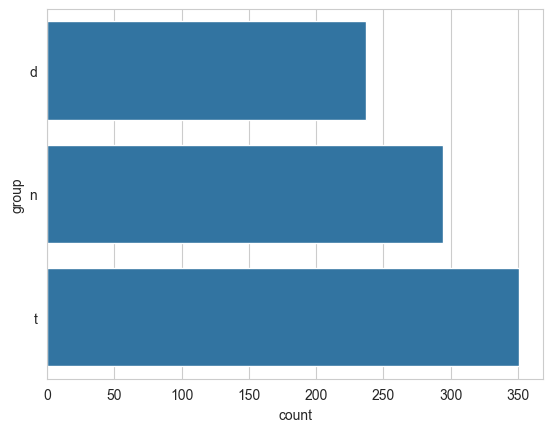

In [4]:
sns.countplot(data=df, y="group");

# Plot

In [5]:
from alphaanalysis import plot as plota
plota.set_rc_params()

In [6]:
order = plota.get_order(indicator=indicator)
palette = plota.get_palette(indicator=indicator)
colors = [palette[group] for group in order]

In [7]:
scan_frequency = 31.25
rf_time = ((np.arange(45) - 7) * 0.032)[::-1]
rf_time

array([ 1.184,  1.152,  1.12 ,  1.088,  1.056,  1.024,  0.992,  0.96 ,
        0.928,  0.896,  0.864,  0.832,  0.8  ,  0.768,  0.736,  0.704,
        0.672,  0.64 ,  0.608,  0.576,  0.544,  0.512,  0.48 ,  0.448,
        0.416,  0.384,  0.352,  0.32 ,  0.288,  0.256,  0.224,  0.192,
        0.16 ,  0.128,  0.096,  0.064,  0.032,  0.   , -0.032, -0.064,
       -0.096, -0.128, -0.16 , -0.192, -0.224])

## Chirp transience response index

-0.421037 1.0


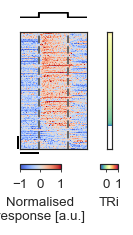

In [8]:
from djimaging.utils.math_utils import padded_vstack

chirp_tris = df['chirp_tri'].values
groups = df['group'].values
soma_dists = df['soma_dist'].values

chirp_avgs = df['chirp_avg'].values
chirp_avgs = padded_vstack(chirp_avgs)[:, :int(np.round(7*scan_frequency))]
extent = (0, int(np.round(7*scan_frequency)) / scan_frequency, 0, chirp_avgs.shape[0])

sidxs = np.argsort(np.nan_to_num(chirp_tris.copy(), 0) + 100 * np.isfinite(chirp_tris))
vabsmax = np.nanmax(np.abs(chirp_avgs))

fig, axs = plt.subplots(3, 2, figsize=(1.1, 2), width_ratios=(15, 1), height_ratios=(1, 20, 1), sharey='row')

ax = axs[0, 0]
plota.plot_chirp(ax=ax, c='k')
ax.set_xlim(0, 7)
ax.set_ylim(-5, 300)
ax.axis('off')

ax = axs[0, 1]
ax.axis('off')

ax = axs[1, 0]
ax.axvline(2, ls='--', c='dimgray')
ax.axvline(5, ls='--', c='dimgray')
im = ax.imshow(chirp_avgs[sidxs], aspect='auto', vmin=-vabsmax, vmax=+vabsmax, cmap='coolwarm', interpolation='none', origin='lower', extent=extent)
plt.colorbar(im, ax=ax, cax=axs[2, 0], orientation='horizontal', label='Normalised\nresponse [a.u.]')
ax.set_xticks([])
ax.set_xlim(extent[0], extent[1])

plota.plot_scale_bar(ax, x0=extent[0], y0=extent[2] - 0.03 * abs(extent[3] - extent[2]), size=2, orientation='h')
plota.plot_scale_bar(ax, x0=extent[0] - 0.03 * abs(extent[1] - extent[0]), y0=0, size=100, orientation='v')

ax.set_yticks([])

vmin = -0.5
vmax = 1

print(np.nanmin(chirp_tris), np.nanmax(chirp_tris))

assert np.nanmin(chirp_tris) >= vmin
assert np.nanmax(chirp_tris) <= vmax

ax = axs[1, 1]
im = ax.imshow(chirp_tris[sidxs, np.newaxis], aspect='auto', cmap='Spectral_r', interpolation='none', origin='lower', vmin=vmin, vmax=vmax)
plt.colorbar(im, ax=ax, cax=axs[2, 1], orientation='horizontal', label='TRi')
ax.set_xticks([])

plt.tight_layout()


plota.change_box(axs=[axs[2, 0]], dx=-0.2)
plota.move_box(axs=[axs[2, 1]], dx=-0.05)
plota.change_box(axs=[axs[2, 1]], dx=+0.1)

plt.savefig(f'./figures/{indicator}_chirp_tri.pdf')
plt.show()

In [9]:
np.nanmin(chirp_tris), np.nanmax(chirp_tris)

(-0.421037, 1.0)

## tRF transience response index

0.0809773 1.70507


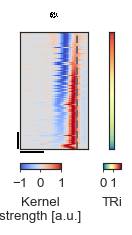

In [10]:
from djimaging.utils.math_utils import padded_vstack

rf_tris = df[df.trf.notnull()]['rf_tri'].values
groups = df[df.trf.notnull()]['group'].values
soma_dists = df[df.trf.notnull()]['soma_dist'].values

trfs = df[df.trf.notnull()]['trf'].values
trfs = np.vstack(trfs)
extent = (rf_time[0], rf_time[-1], 0, trfs.shape[0])

sidxs = np.argsort(np.nan_to_num(rf_tris.copy(), 0) + 100 * np.isfinite(rf_tris))
vabsmax = np.nanmax(np.abs(trfs))

fig, axs = plt.subplots(3, 2, figsize=(1.1, 2), width_ratios=(15, 1), height_ratios=(1, 20, 1), sharey='row')

ax = axs[0, 0]
plota.plot_noise(ax=ax)
ax.axis('off')

ax = axs[0, 1]
ax.axis('off')

ax = axs[1, 0]
ax.axvline(2, ls='--', c='dimgray')
ax.axvline(5, ls='--', c='dimgray')
im = ax.imshow(trfs[sidxs], aspect='auto', vmin=-vabsmax, vmax=+vabsmax, cmap='coolwarm', interpolation='none', origin='lower', extent=extent)
plt.colorbar(im, ax=ax, cax=axs[2, 0], orientation='horizontal', label='Kernel\nstrength [a.u.]')

ax.set_xticks([])
ax.set_xlim(extent[0], extent[1])

plota.plot_scale_bar(ax, x0=extent[0] - 0.5, y0=extent[2] - 0.03 * abs(extent[3] - extent[2]), size=0.5, orientation='h')
plota.plot_scale_bar(ax, x0=extent[0] + 0.03 * abs(extent[1] - extent[0]), y0=0, size=100, orientation='v')

ax.axvline(0, ls='--', c='dimgray')
ax.set_yticks([])

vmin = 0
vmax = 1.75

print(np.nanmin(rf_tris), np.nanmax(rf_tris))

assert np.nanmin(rf_tris) >= vmin
assert np.nanmax(rf_tris) <= vmax

ax = axs[1, 1]
im = ax.imshow(rf_tris[sidxs, np.newaxis], aspect='auto', vmin=vmin, vmax=vmax, cmap='Spectral_r', interpolation='none', origin='lower')
plt.colorbar(im, ax=ax, cax=axs[2, 1], orientation='horizontal', label='TRi')
ax.set_xticks([])

plt.tight_layout()


plota.change_box(axs=[axs[2, 0]], dx=-0.2)
plota.move_box(axs=[axs[2, 1]], dx=-0.05)
plota.change_box(axs=[axs[2, 1]], dx=+0.1)

plt.savefig(f'./figures/{indicator}_noise_tri.pdf')
plt.show()

## Compare chirp and noise TRi

In [11]:
col2label = {
    "rf_tri": 'Noise TRi',
    "chirp_tri": 'Chirp TRi',
    "soma_dist": 'Dend. dist. to soma [µm]',
    "surround_index": 'Noise surround index',
}

In [12]:
import pingouin as pg

def plot_panel(ax1, df_plot, x, y, ax2=None):
    groups = df_plot.group.unique()
    
    for i, group in enumerate(groups):
        group_df = df_plot[df_plot.group==group]

        scatter_kws=dict(s=3, alpha=0.7 - (i/10), ec='none')
        
        plota.plot_regression(ax=ax1, x=group_df[x], y=group_df[y], c=palette[group], scatter_kwargs=scatter_kws)
        sns.boxplot(ax=ax2, data=group_df, x='group', y=y, palette=palette, fliersize=0, order=order)
    
    ax1.legend(loc='lower left', bbox_to_anchor=(0.05, 1), handlelength=0.3)
    ax1.set(xlabel=col2label[x], ylabel=col2label[y])
    ax2.axis('off')
    

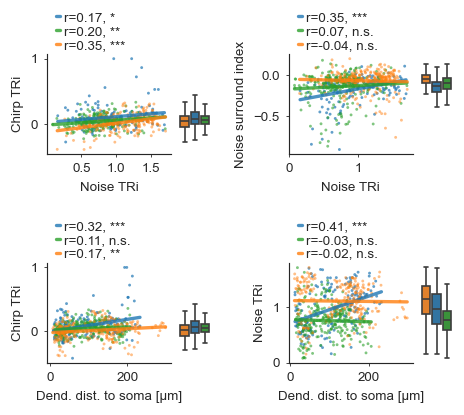

In [13]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

df_plot = df

fig, axs = plt.subplots(2, 5, figsize=(4, 3.5), width_ratios=(4, 1, 2, 4, 1))
sns.despine()

plot_panel(ax1=axs[0, 0], df_plot=df_plot, x='rf_tri', y='chirp_tri', ax2=axs[0, 1])
plot_panel(ax1=axs[1, 0], df_plot=df_plot, x='soma_dist', y='chirp_tri', ax2=axs[1, 1])

for ax in axs[:, 2]:
    ax.axis('off')

plot_panel(ax1=axs[0, 3], df_plot=df_plot, x='rf_tri', y='surround_index', ax2=axs[0, 4])
plot_panel(ax1=axs[1, 3], df_plot=df_plot, x='soma_dist', y='rf_tri', ax2=axs[1, 4])

plt.tight_layout(w_pad=-4, h_pad=2)
#plt.savefig(f'./figures/{indicator}_noise_vs_chirp_rf_tri.pdf')
plt.show()

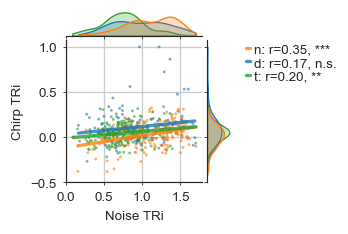

In [14]:
x='rf_tri'
y='chirp_tri'

scatter_kws = dict(s=3, alpha=0.6, ec='none')
jp = sns.jointplot(data=df_plot, x=x, y=y, hue='group', kind='scatter', marginal_kws=dict(cut=0, common_norm=False), joint_kws=scatter_kws, height=2, legend=False,
                   palette=palette, hue_order=order)

for i, group in enumerate(order):
    group_df = df_plot[df_plot.group==group]
    plota.plot_regression(ax=jp.ax_joint, x=group_df[x], y=group_df[y], c=palette[group], scatter_kwargs=dict(s=0), label=f"{group}: ", n_tests=len(order), robust=False)

jp.ax_joint.legend(loc='upper left', bbox_to_anchor=(1.3, 1), handlelength=0.3)

jp.ax_joint.set(xlabel=col2label[x], ylabel=col2label[y])
jp.ax_joint.grid()
jp.ax_marg_y.set_yticks([-0.5, 0, 0.5, 1])
jp.ax_marg_x.set_xticks([0, 0.5, 1, 1.5])
plt.savefig(f'./figures/{indicator}_noise_vs_chirp_rf_tri.pdf', bbox_inches='tight')

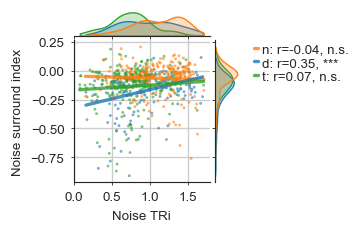

In [15]:
x='rf_tri'
y='surround_index'

scatter_kws = dict(s=3, alpha=0.6, ec='none')
jp = sns.jointplot(data=df_plot, x=x, y=y, hue='group', kind='scatter', marginal_kws=dict(cut=0, common_norm=False), joint_kws=scatter_kws, height=2, legend=False,
                   palette=palette, hue_order=order)

for i, group in enumerate(order):
    group_df = df_plot[df_plot.group==group]
    plota.plot_regression(ax=jp.ax_joint, x=group_df[x], y=group_df[y], c=palette[group], scatter_kwargs=dict(s=0), label=f"{group}: ", n_tests=len(order), robust=False)

jp.ax_joint.legend(loc='upper left', bbox_to_anchor=(1.3, 1), handlelength=0.3)

jp.ax_joint.set(xlabel=col2label[x], ylabel=col2label[y])
jp.ax_joint.grid()
jp.ax_marg_x.set_xticks([0, 0.5, 1, 1.5])
plt.savefig(f'./figures/{indicator}_noise_tri_vs_surround.pdf', bbox_inches='tight')

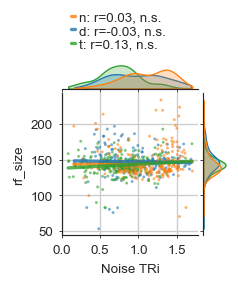

In [16]:
x='rf_tri'
y='rf_size'

scatter_kws = dict(s=3, alpha=0.6, ec='none')
jp = sns.jointplot(data=df_plot, x=x, y=y, hue='group', kind='scatter', marginal_kws=dict(cut=0, common_norm=False), joint_kws=scatter_kws, height=2, legend=False,
                   palette=palette, hue_order=order)

for i, group in enumerate(order):
    group_df = df_plot[df_plot.group==group]
    plota.plot_regression(ax=jp.ax_joint, x=group_df[x], y=group_df[y], c=palette[group], scatter_kwargs=dict(s=0), label=f"{group}: ", n_tests=len(order), robust=False)

jp.ax_joint.legend(loc='upper left', bbox_to_anchor=(0.05, 1.6), handlelength=0.3)

jp.ax_joint.set(xlabel=col2label[x], ylabel=col2label.get(y, y))
jp.ax_joint.grid()
jp.ax_marg_x.set_xticks([0, 0.5, 1, 1.5])
plt.savefig(f'./figures/{indicator}_noise_tri_vs_size.pdf', bbox_inches='tight')